# Samples × Signs (LIBRAS MINDS and LIBRAS UFOP)

This notebook reads `libras_minds_openpose.csv` and `libras_ufop_openpose.csv`, counts samples per sign (unique videos), and plots two bar charts. The Y-axis is limited to 40–70.

X-axis settings:
- MINDS: signs sorted alphabetically.
- UFOP: signs sorted numerically, with tick labels every 5 (1, 5, 10, 15, ...).

Notes:
- “Samples” here means unique videos per sign (`video_name` nunique).
- If files aren’t in the project root, the code looks in `00_datasets/dataset_output/...`.


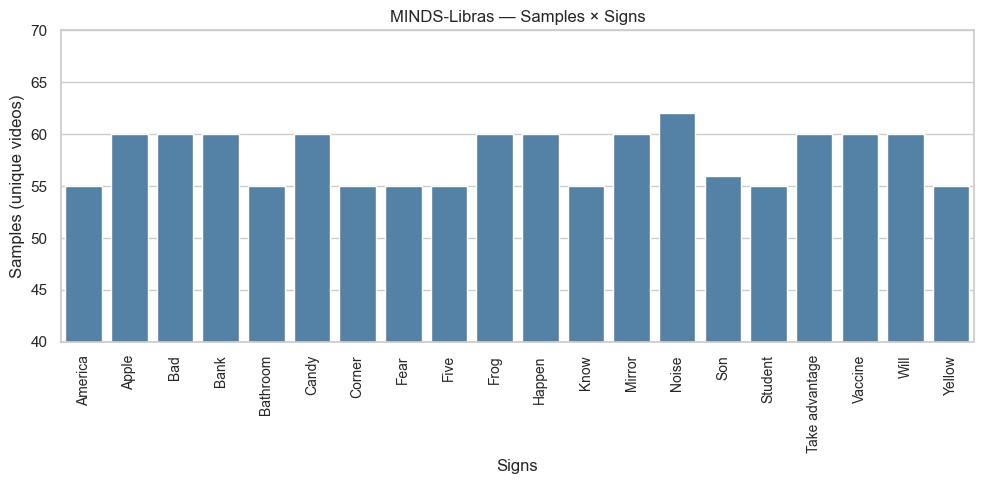

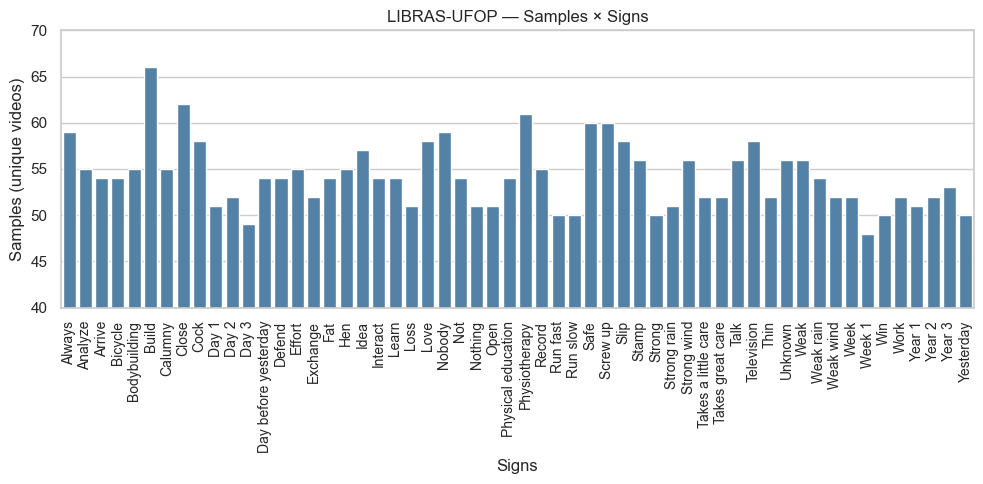

In [1]:
# Imports and setup
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Utilities

def find_csv(preferred_filename: str, fallback_dir: str) -> str:
    """Return an existing path for the CSV, trying project root and 00_datasets/dataset_output/<fallback_dir>/.
    preferred_filename: e.g., "libras_minds_openpose.csv"
    fallback_dir: e.g., "libras_minds" or "libras_ufop"
    """
    candidates = [
        os.path.join(".", preferred_filename),
        os.path.join(".", "00_datasets", "dataset_output", fallback_dir, preferred_filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(
        f"File {preferred_filename} not found. Looked in: {candidates}"
    )

# ID -> sign names mapping for LIBRAS UFOP (English)
UFOP_SIGN_NAMES = {
    1: "Year 1", 2: "Year 2", 3: "Year 3",
    4: "Day 1", 5: "Day 2", 6: "Day 3",
    7: "Week 1", 8: "Week", 9: "Yesterday", 10: "Day before yesterday",
    11: "Safe", 12: "Physiotherapy", 13: "Idea", 14: "Stamp", 15: "Record",
    16: "Effort", 17: "Defend", 18: "Physical education", 19: "Bodybuilding",
    20: "Battle", 21: "Close", 22: "Screw up", 23: "Bicycle", 24: "Slip",
    25: "Always", 26: "Build", 27: "Calumny", 28: "Work", 29: "Television",
    30: "Love", 31: "Learn", 32: "Analyze", 33: "Talk", 34: "Cock", 35: "Hen",
    36: "Interact", 37: "Exchange", 38: "Strong wind", 39: "Weak wind",
    40: "Strong rain", 41: "Weak rain", 42: "Run fast", 43: "Run slow",
    44: "Takes great care", 45: "Takes a little care", 46: "Thin", 47: "Fat",
    48: "Strong", 49: "Weak", 50: "Arrive", 51: "Win", 52: "Loss", 53: "Open",
    54: "Nothing", 55: "Nobody", 56: "Not", 57: "Unknown"
}

# MINDS signs mapping (Portuguese -> English)
MINDS_SIGN_NAMES_EN = {
    "Acontecer": "Happen",
    "Aluno": "Student",
    "Amarelo": "Yellow",
    "America": "America",
    "América": "America",
    "Aproveitar": "Take advantage",
    "Bala": "Candy",
    "Banco": "Bank",
    "Banheiro": "Bathroom",
    "Barulho": "Noise",
    "Cinco": "Five",
    "Conhecer": "Know",
    "Espelho": "Mirror",
    "Esquina": "Corner",
    "Filho": "Son",
    "Maca": "Apple",
    "Maçã": "Apple",
    "Medo": "Fear",
    "Ruim": "Bad",
    "Sapo": "Frog",
    "Vacina": "Vaccine",
    "Vontade": "Will",
}


def plot_samples_per_category(
    csv_path: str,
    title: str,
    ylim=(40, 70),
    *,
    sort_mode="count_desc",
    tick_step=None,
    label_map=None,
):
    """Read the CSV, count samples (unique videos) per sign, and plot a bar chart.

    Extra parameters:
    - sort_mode: "count_desc" (default), "alpha" (alphabetical by raw labels),
                 "alpha_mapped" (alphabetical by mapped English labels),
                 "numeric" (numeric order of the raw label).
    - tick_step: show only one x-tick label every `tick_step` bars (e.g., 5 for every 5 bars).
    - label_map: optional dict to replace x-axis labels after ordering or to drive mapped sorting.
    """
    df = pd.read_csv(csv_path)

    # Detect label column (category or sign)
    label_col = None
    if "category" in df.columns:
        label_col = "category"
    elif "sign" in df.columns:
        label_col = "sign"
    else:
        raise KeyError(
            f"Label column not found ('category' or 'sign') in {csv_path}. Columns: {list(df.columns)[:12]}..."
        )

    # Count samples: unique videos per label
    if "video_name" in df.columns:
        counts = df.groupby(label_col)["video_name"].nunique()
    else:
        counts = df[label_col].value_counts()

    # Helper to map a raw label to its mapped/English form for sorting
    def map_label_for_sort(k):
        if label_map is None:
            return str(k)
        # try direct
        v = label_map.get(k)
        if v is None:
            try:
                key_int = int(str(k))
                v = label_map.get(key_int)
            except Exception:
                pass
        if v is None:
            v = label_map.get(str(k))
        return str(v) if v is not None else str(k)

    # X ordering
    if sort_mode == "alpha_mapped" and label_map is not None:
        ordered_index = sorted(counts.index, key=lambda s: map_label_for_sort(s).lower())
        counts = counts.reindex(ordered_index)
    elif sort_mode == "alpha":
        ordered_index = sorted(counts.index, key=lambda s: str(s).lower())
        counts = counts.reindex(ordered_index)
    elif sort_mode == "numeric":
        try:
            ordered_index = sorted(counts.index, key=lambda s: int(str(s)))
        except Exception:
            ordered_index = sorted(counts.index, key=lambda s: str(s))
        counts = counts.reindex(ordered_index)
    else:  # "count_desc"
        counts = counts.sort_values(ascending=False)

    # Final x labels (after ordering)
    labels = list(counts.index)
    if label_map is not None:
        labels = [map_label_for_sort(k) for k in labels]

    y_label = "Samples (unique videos)" if "video_name" in df.columns else "Samples"

    plt.figure(figsize=(10, 5), dpi=100)
    ax = sns.barplot(x=list(range(len(counts))), y=list(counts.values), color="steelblue")
    plt.ylim(*ylim)
    plt.xlabel("Signs")
    plt.ylabel(y_label)
    plt.title(title)

    # X tick labels
    if tick_step and tick_step > 1:
        positions = list(range(0, len(labels), tick_step))
        ax.set_xticks(positions)
        ax.set_xticklabels([labels[i] for i in positions], rotation=90, fontsize=10)
    else:
        ax.set_xticks(list(range(len(labels))))
        ax.set_xticklabels(labels, rotation=90, fontsize=10)

    plt.tight_layout()
    plt.show()


# Locate CSVs
minds_csv = find_csv("libras_minds_openpose.csv", "libras_minds")
ufop_csv = find_csv("libras_ufop_openpose.csv", "libras_ufop")

# Plot with Y in [40, 70]
# MINDS: alphabetical by English labels
plot_samples_per_category(
    minds_csv,
    "MINDS-Libras — Samples × Signs",
    ylim=(40, 70),
    sort_mode="alpha_mapped",
    label_map=MINDS_SIGN_NAMES_EN,
)

# UFOP: alphabetical by English labels, show labels every 5
plot_samples_per_category(
    ufop_csv,
    "LIBRAS-UFOP — Samples × Signs",
    ylim=(40, 70),
    sort_mode="alpha_mapped",
    # tick_step=5,
    label_map=UFOP_SIGN_NAMES,
)


UFOP_SIGN_NAMES = {
    1: "Ano 1", 2: "Ano 2", 3: "Ano 3",
    4: "Dia 1", 5: "Dia 2", 6: "Dia 3",
    7: "Semana 1", 8: "Semana", 9: "Ontem", 10: "Anteontem",
    11: "Seguro", 12: "Fisioterapia", 13: "Ideia", 14: "Carimbo", 15: "Registro",
    16: "Esforço", 17: "Defesa", 18: "Educação física", 19: "Musculação",
    20: "Batalha", 21: "Fechar", 22: "Estragar", 23: "Bicicleta", 24: "Escorregar",
    25: "Sempre", 26: "Construir", 27: "Calúnia", 28: "Trabalho", 29: "Televisão",
    30: "Amor", 31: "Aprender", 32: "Analisar", 33: "Conversar", 34: "Galo", 35: "Galinha",
    36: "Interagir", 37: "Trocar", 38: "Vento forte", 39: "Vento fraco",
    40: "Chuva forte", 41: "Chuva fraca", 42: "Correr rápido", 43: "Correr devagar",
    44: "Toma muito cuidado", 45: "Toma pouco cuidado", 46: "Magro", 47: "Gordo",
    48: "Forte", 49: "Fraco", 50: "Chegar", 51: "Vencer", 52: "Perder", 53: "Abrir",
    54: "Nada", 55: "Ninguém", 56: "Não", 57: "Desconhecido"
}


In [3]:
# LIBRAS-UFOP: nome do vídeo e quantidade de frames, com menor e maior valor
df_ufop = pd.read_csv(ufop_csv)

if "video_name" not in df_ufop.columns:
    raise KeyError("A coluna 'video_name' não foi encontrada no CSV do UFOP.")

# Se existir coluna de frame, usa número de frames únicos; senão, usa total de linhas por vídeo
if "frame" in df_ufop.columns:
    frames_por_video = df_ufop.groupby("video_name")["frame"].nunique()
else:
    frames_por_video = df_ufop.groupby("video_name").size()

resumo = (
    frames_por_video
    .reset_index(name="qtd_frames")
    .sort_values("qtd_frames", ascending=True)
    .reset_index(drop=True)
)

print("Vídeo e quantidade de frames:")
print(resumo.to_string(index=False))

min_frames = resumo["qtd_frames"].min()
max_frames = resumo["qtd_frames"].max()

print("\nMenor quantidade de frames:")
print(resumo[resumo["qtd_frames"] == min_frames].to_string(index=False))

print("\nMaior quantidade de frames:")
print(resumo[resumo["qtd_frames"] == max_frames].to_string(index=False))

Vídeo e quantidade de frames:
  video_name  qtd_frames
 p3_c2_s1_12          28
 p5_c2_s12_9          31
p2_c4_s11_11          31
  p4_c2_s8_9          33
p2_c2_s12_11          34
 p2_c4_s12_9          34
 p5_c2_s1_10          34
 p1_c3_s4_11          35
 p4_c2_s1_10          35
 p4_c4_s12_9          35
  p3_c4_s7_9          35
  p2_c4_s7_9          36
 p2_c4_s9_11          36
 p4_c4_s11_9          36
 p3_c2_s6_11          36
  p5_c1_s7_4          36
 p2_c2_s1_12          36
 p4_c3_s4_10          37
  p2_c2_s6_9          37
 p2_c2_s8_10          37
p3_c2_s16_14          37
 p5_c3_s4_10          37
  p5_c1_s7_9          37
 p5_c1_s10_9          37
 p5_c2_s8_10          37
  p2_c2_s5_9          38
p4_c2_s12_10          38
p3_c2_s19_11          38
 p5_c2_s2_10          38
 p1_c4_s3_11          38
p3_c1_s10_12          38
 p3_c2_s3_11          38
  p2_c4_s5_9          38
p1_c4_s12_13          39
  p5_c2_s6_9          39
 p5_c4_s12_9          39
 p2_c2_s2_11          39
p3_c2_s12_11        

In [13]:
# Lista vídeos com menor e maior quantidade de frames (com sign, video_name e participant_id)

if "video_name" not in df_ufop.columns:
    raise KeyError("A coluna 'video_name' não foi encontrada no CSV do UFOP.")
if "participant_id" not in df_ufop.columns:
    raise KeyError("A coluna 'participant_id' não foi encontrada no CSV do UFOP.")

# Detecta a coluna de sinal
if "sign" in df_ufop.columns:
    label_col = "sign"
elif "category" in df_ufop.columns:
    label_col = "category"
else:
    raise KeyError("Nenhuma coluna de sinal encontrada ('sign' ou 'category').")

# Conta frames por vídeo
if "frame" in df_ufop.columns:
    frames_por_video = df_ufop.groupby("video_name")["frame"].nunique()
else:
    frames_por_video = df_ufop.groupby("video_name").size()

# Metadados por vídeo
meta_video = (
    df_ufop.groupby("video_name", as_index=False)
    .agg({label_col: "first", "participant_id": "first"})
    .rename(columns={label_col: "sign"})
)

resumo_video = (
    frames_por_video
    .reset_index(name="qtd_frames")
    .merge(meta_video, on="video_name", how="left")
)

min_frames = resumo_video["qtd_frames"].min()
max_frames = resumo_video["qtd_frames"].max()

videos_menor = resumo_video.loc[
    resumo_video["qtd_frames"] == min_frames, ["sign", "video_name", "participant_id"]
].sort_values(["sign", "video_name"])

videos_maior = resumo_video.loc[
    resumo_video["qtd_frames"] == max_frames, ["sign", "video_name", "participant_id"]
].sort_values(["sign", "video_name"])

print(f"Vídeos com MENOR quantidade de frames ({min_frames}):")
print(videos_menor.to_string(index=False))

print(f"\nVídeos com MAIOR quantidade de frames ({max_frames}):")
print(videos_maior.to_string(index=False))

Vídeos com MENOR quantidade de frames (28):
 sign  video_name  participant_id
   11 p3_c2_s1_12             3.0

Vídeos com MAIOR quantidade de frames (121):
 sign video_name  participant_id
   14 p3_c2_s4_1             3.0


In [15]:
# Vídeo(s) com quantidade de frames mais próxima da média (UFOP)
if "resumo_video" not in globals():
	raise NameError("A variável 'resumo_video' não existe. Execute a célula que cria o resumo do UFOP primeiro.")

if "media_frames" not in globals():
	media_frames = resumo_video["qtd_frames"].mean()

df_media = resumo_video.copy()
df_media["dist_media"] = (df_media["qtd_frames"] - media_frames).abs()

min_dist = df_media["dist_media"].min()
videos_media = df_media.loc[
	df_media["dist_media"] == min_dist,
	["sign", "video_name", "participant_id", "qtd_frames"]
].sort_values(["qtd_frames", "sign", "video_name"])

print(f"Média de frames: {media_frames:.2f}")
print("Vídeo(s) mais próximo(s) da média:")
print(videos_media.to_string(index=False))

Média de frames: 66.61
Vídeo(s) mais próximo(s) da média:
 sign   video_name  participant_id  qtd_frames
    1   p3_c1_s1_8             3.0          67
    1   p5_c1_s1_6             5.0          67
    3  p1_c1_s3_10             1.0          67
    3   p1_c1_s3_4             1.0          67
    3  p2_c1_s3_10             2.0          67
    4   p1_c1_s4_9             1.0          67
    4   p2_c1_s4_4             2.0          67
    4   p3_c1_s4_0             3.0          67
    5   p3_c1_s5_7             3.0          67
    6   p3_c1_s6_0             3.0          67
    6   p3_c1_s6_6             3.0          67
    8   p5_c1_s8_0             5.0          67
    9   p1_c1_s9_0             1.0          67
   13   p1_c2_s3_4             1.0          67
   13   p1_c2_s3_5             1.0          67
   13   p1_c2_s3_6             1.0          67
   13   p1_c2_s3_8             1.0          67
   15   p1_c2_s5_6             1.0          67
   15   p3_c2_s5_1             3.0          67
  

In [11]:
# LIBRAS-MINDS: vídeos com menor e maior quantidade de frames (sign e video_name)
df_minds = pd.read_csv(minds_csv)

if "video_name" not in df_minds.columns:
    raise KeyError("A coluna 'video_name' não foi encontrada no CSV do MINDS.")

# Detecta a coluna de sinal
if "sign" in df_minds.columns:
    label_col = "sign"
elif "category" in df_minds.columns:
    label_col = "category"
else:
    raise KeyError("Nenhuma coluna de sinal encontrada ('sign' ou 'category').")

# Conta frames por vídeo
if "frame" in df_minds.columns:
    frames_por_video_minds = df_minds.groupby("video_name")["frame"].nunique()
else:
    frames_por_video_minds = df_minds.groupby("video_name").size()

# Metadados por vídeo (sign)
meta_video_minds = (
    df_minds.groupby("video_name", as_index=False)[label_col]
    .first()
    .rename(columns={label_col: "sign"})
)

resumo_video_minds = (
    frames_por_video_minds
    .reset_index(name="qtd_frames")
    .merge(meta_video_minds, on="video_name", how="left")
)

min_frames_minds = resumo_video_minds["qtd_frames"].min()
max_frames_minds = resumo_video_minds["qtd_frames"].max()

videos_menor_minds = resumo_video_minds.loc[
    resumo_video_minds["qtd_frames"] == min_frames_minds, ["sign", "video_name"]
].sort_values(["sign", "video_name"])

videos_maior_minds = resumo_video_minds.loc[
    resumo_video_minds["qtd_frames"] == max_frames_minds, ["sign", "video_name"]
].sort_values(["sign", "video_name"])

print(f"MINDS - Vídeos com MENOR quantidade de frames ({min_frames_minds}):")
print(videos_menor_minds.to_string(index=False))

print(f"\nMINDS - Vídeos com MAIOR quantidade de frames ({max_frames_minds}):")
print(videos_maior_minds.to_string(index=False))

MINDS - Vídeos com MENOR quantidade de frames (71):
      sign                      video_name
Aproveitar 05AproveitarSinalizador08-1.mp4

MINDS - Vídeos com MAIOR quantidade de frames (233):
 sign                 video_name
Aluno 02AlunoSinalizador12-1.mp4


In [4]:
media_frames = resumo["qtd_frames"].mean()
print(f"Média de frames total: {media_frames:.2f}")

Média de frames total: 66.61


In [9]:
cabecalho_ufop = pd.read_csv(minds_csv, nrows=0).columns.tolist()
print("Cabeçalho do ufop_csv:")
print(cabecalho_ufop)

Cabeçalho do ufop_csv:
['Unnamed: 0', 'sign', 'video_name', 'frame_id', 'hand_0_0_x', 'hand_0_0_y', 'hand_0_0_z', 'hand_0_1_x', 'hand_0_1_y', 'hand_0_1_z', 'hand_0_2_x', 'hand_0_2_y', 'hand_0_2_z', 'hand_0_3_x', 'hand_0_3_y', 'hand_0_3_z', 'hand_0_4_x', 'hand_0_4_y', 'hand_0_4_z', 'hand_0_5_x', 'hand_0_5_y', 'hand_0_5_z', 'hand_0_6_x', 'hand_0_6_y', 'hand_0_6_z', 'hand_0_7_x', 'hand_0_7_y', 'hand_0_7_z', 'hand_0_8_x', 'hand_0_8_y', 'hand_0_8_z', 'hand_0_9_x', 'hand_0_9_y', 'hand_0_9_z', 'hand_0_10_x', 'hand_0_10_y', 'hand_0_10_z', 'hand_0_11_x', 'hand_0_11_y', 'hand_0_11_z', 'hand_0_12_x', 'hand_0_12_y', 'hand_0_12_z', 'hand_0_13_x', 'hand_0_13_y', 'hand_0_13_z', 'hand_0_14_x', 'hand_0_14_y', 'hand_0_14_z', 'hand_0_15_x', 'hand_0_15_y', 'hand_0_15_z', 'hand_0_16_x', 'hand_0_16_y', 'hand_0_16_z', 'hand_0_17_x', 'hand_0_17_y', 'hand_0_17_z', 'hand_0_18_x', 'hand_0_18_y', 'hand_0_18_z', 'hand_0_19_x', 'hand_0_19_y', 'hand_0_19_z', 'hand_0_20_x', 'hand_0_20_y', 'hand_0_20_z', 'hand_1_0_x',